<a href="https://colab.research.google.com/github/Hieu0469/Do-An-2/blob/main/WaSR%20Resnet50%20imu/Pruned_Quantized_WaSR_ResNet50_imu_Cityscapes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
!export KAGGLE_API_TOKEN=KGAT_23df003775d3655034a233879b9dbf19

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

electraawais_cityscape_dataset_path = kagglehub.dataset_download('electraawais/cityscape-dataset')
# hillsp_wasr_resnet50_imu_pytorch_default_1_path = kagglehub.model_download('hillsp/wasr-resnet50-imu/PyTorch/default/3')
hillsp_pruned_ewasr_resnet50_imu_cityscapes_2_pytorch_default_1_path = kagglehub.model_download('hillsp/pruned-wasr-resnet50-imu-cityscapes/PyTorch/default/1')

print('Data source import complete.')


100%|██████████| 11.0G/11.0G [01:14<00:00, 158MB/s]

Extracting files...



100%|██████████| 182/182 [00:00<00:00, 399kB/s]



100%|██████████| 120/120 [00:00<00:00, 36.5kB/s]



  0%|          | 0.00/255M [00:00<?, ?B/s]



100%|██████████| 158/158 [00:00<00:00, 537kB/s]




  0%|          | 0.00/211M [00:00<?, ?B/s]




  0%|          | 0.00/211M [00:00<?, ?B/s]





100%|██████████| 119/119 [00:00<00:00, 136kB/s]

  0%|          | 1.00M/255M [00:00<01:40, 2.64MB/s]

  0%|          | 1.00M/211M [00:00<01:25, 2.59MB/s]


  0%|          | 1.00M/211M [00:00<01:31, 2.41MB/s]
  1%|          | 3.00M/255M [00:00<00:39, 6.65MB/s]

  1%|▏         | 3.00M/211M [00:00<00:33, 6.54MB/s]


  1%|          | 2.00M/211M [00:00<00:51, 4.24MB/s]
  2%|▏         | 6.00M/255M [00:00<00:23, 11.3MB/s]

  3%|▎         | 6.00M/211M [00:00<00:18, 11.6MB/s]


  2%|▏         | 4.00M/211M [00:00<00:27, 7.79MB/s]
  4%|▍         | 10.0M/255M [00:00<00:13, 18.6MB/s]

  5%|▌         | 11.0M/211M [00:00<00:09, 21.2MB/s]


  4%|▍         | 8.00M/211M [00:00<00:13, 15.8MB/s]

  8%|▊         | 17.0M/211M [00:00<00:06, 31.9MB/s]
  5%|▌         | 13.0M/255M [00:00<00:12, 20.5MB/s]


  6%|▌         | 12.0M/211M [00:00<00:09, 22.1MB/s]

 10%|█         | 22.0M/211M [00:01<00:05, 35.7MB/s]
  8%|▊         | 20.0M/255M [00:01<00:07, 31.9MB/s]


  8%|▊         | 17.0M/211M [00:01<00:06, 29.

Data source import complete.


<a href="https://colab.research.google.com/github/Coder0469/Do-an-1/blob/main/Week3/B2_basic_pipeline_PASCALVOC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="markdown-google-sans">
  <h3>Kiểm tra GPU được cấp phát</h3>
</div>

In [ ]:
model_name = 'quantized_pruned_wasr_resnet50_imu'
save_path = "{}.pth".format(model_name)
# base_load_path = hillsp_wasr_resnet50_imu_pytorch_default_1_path + '/wasr_resnet50_imu.pth'
prune_load_path =  hillsp_pruned_ewasr_resnet50_imu_cityscapes_2_pytorch_default_1_path + '/pruned_ewasr_resnet18_imu.pth'
# prune_load_path = None
quantized_load_path = "/content/quantized_pruned_wasr_resnet50_imu_quantized_final.onnx"
trainsize = 256
n_eps = 100
learning_rate = 1e-4
Num_classes = 34

In [ ]:
!nvidia-smi

Fri Mar 27 14:43:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 21.2 MB/s eta 0:00:00


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 28.1 MB/s eta 0:00:00


In [ ]:
!pip install onnx

In [ ]:
!pip install --upgrade onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 111.1 MB/s eta 0:00:00


In [ ]:
!pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.5 MB/s eta 0:00:00


<div class="markdown-google-sans">
  <h3>Import thư viện</h3>
</div>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchmetrics import  JaccardIndex
from torchmetrics.segmentation import DiceScore
import albumentations as A
from albumentations.pytorch import ToTensorV2 # np.array -> torch.tensor
import os
from tqdm import tqdm
from glob import glob
import time
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF
from PIL import Image
import segmentation_models_pytorch as smp
import sys

In [ ]:
!git clone https://github.com/Coder0469/eWaSR2
!git clone https://github.com/Coder0469/MyTorchPruning.git

Cloning into 'eWaSR2'...
remote: Enumerating objects: 195, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 195 (delta 100), reused 84 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (195/195), 1.04 MiB | 19.63 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Cloning into 'MyTorchPruning'...
remote: Enumerating objects: 7126, done.
remote: Counting objects: 100% (7126/7126), done.
remote: Compressing objects: 100% (2341/2341), done.
remote: Total 7126 (delta 4713), reused 7107 (delta 4706), pack-reused 0 (from 0)
Receiving objects: 100% (7126/7126), 10.27 MiB | 18.48 MiB/s, done.
Resolving deltas: 100% (4713/4713), done.


In [ ]:
!cd MyTorchPruning && pip install -e .

Obtaining file:///content/MyTorchPruning
  Preparing metadata (setup.py) ... done
  Running setup.py develop for torch-pruning


In [ ]:
sys.path.append("/kaggle/working/MyTorchPruning")
sys.path.append("/kaggle/working/eWaSR2")
sys.path.append("/content/MyTorchPruning")

In [ ]:
# !pip uninstall -y tensorboard dataflow protobuf
# !pip install protobuf==3.20.* tensorboard==2.13.*

In [ ]:
!pip install -r eWaSR2/requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 23.0 MB/s eta 0:00:00


<div class="markdown-google-sans">
  <h3>Định nghĩa Dataset</h3>
</div>
Viết class kế thừa từ class Dataset cung cấp sẵn trong PyTorch để đọc dữ liệu từ ổ cứng. Yêu cầu viết đủ 3 hàm __init__() để khởi tạo class, __len__() để trả về số điểm dữ liệu có trong tập dữ liệu và __getitem__() trả về 1 điểm dữ liệu cụ thể. Trong phần này, do tập dữ liệu PASCAL VOC đã rất phổ biến nên sẽ tận dụng Class Dataset đã được viết sẵn. Tham khảo thêm: https://albumentations.ai/docs/autoalbument/examples/pascal_voc/


(1024, 2048)


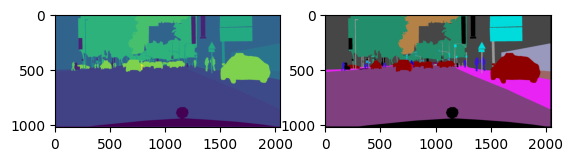

In [ ]:
import os

img_path = os.path.join(electraawais_cityscape_dataset_path, "Fine Annotations/gtFine/train/aachen/aachen_000005_000019_gtFine_labelIds.png")
mask_path = os.path.join(electraawais_cityscape_dataset_path, "Fine Annotations/gtFine/train/aachen/aachen_000005_000019_gtFine_color.png")

img = cv2.imread(img_path)
mask = cv2.imread(mask_path)

if img is None:
    print(f"Error: Could not load image from {img_path}")
else:
    img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # mask = cv2.cvtColor(mask,cv2.COLOR_BGR2RGB)
    print(img.shape)
    plt.subplot(121)
    plt.imshow(img)
    plt.subplot(122)
    plt.imshow(mask)
    # print(torch.unique(torch.from_numpy(mask.reshape(-1,3)),dim=0))

In [ ]:

COLORMAP = [
        [  0,   0,   0],  #0: background
        [0, 0, 0],
        [  0,   0, 255],  #1
        [  0, 220, 220],  #2
        [200, 200, 0],  #3: backward-faced sign
        [ 60,  20, 220],  #4
        [ 70,  70,  70],  #5
        [ 200,   0,  200],  #6: road
        [150,  250, 150],  #7: sidewalk
        [142,   0,   0],  #8
        [153, 153, 153],  #9
        [70, 70, 70],  #10: building
        [156, 102, 102],  #11
        [180, 130,  70],  #12
        [230,   0,   0],  #13: forward-faced sign
        [232,  35, 244],  #14: footbridge
        [150, 150, 75],  #15
        [90, 90, 120],  #16 pole/fence
        [156, 102, 102],  #17
        [0, 35,  70],  #18: traffic light
        [230,   0,   0],  #19
        [0,  70, 0],  #20: tree
        [0, 100, 0],  #21: grass
        [70, 130, 180],  #22: sky
        [128, 128, 0],  #23: pedestrian
        [255, 0, 0],  #24: biker
        [120,0,0],  #25: car
        [0,0,128],  #26
        [0,50,128],  #27: truck/bus
        [20,50,90],  #28
        [20,180,100],  #29
        [70,160,40],  #30
        [45,80,20],  #31: motorbike
        [20,160,140],  #32: bike
        [120,120,120]
]

names = [
    "background",     # 0
    "None",           # 1
    "None",           # 2
    "None",           # 3
    "backward-faced sign",     # 4
    "None",           # 5
    "None",           # 6
    "road",           # 7
    "sidewalk",       # 8
    "None",           # 9
    "None",           # 10
    "building",       # 11
    "None",           # 12
    "None",           # 13
    "forward-faced sign",           # 14
    "footbridge",     # 15
    "None",           # 16
    "pole/fence",          # 17
    "None",           # 18
    "traffic light",  # 19
    "None",           # 20
    "tree",           # 21
    "grass",          # 22
    "sky",            # 23
    "pedestrian",     # 24
    "biker",          # 25
    "car",            # 26
    "None",           # 27
    "truck/bus",      # 28
    "None",           # 29
    "None",           # 30
    "None",           # 31
    "motorbike",      # 32
    "bike",           # 33
    "None"            # 34
]

In [ ]:
def Color(mask):
    color_mask = np.zeros((*mask.shape, 3),dtype = np.uint8)
    for i, color in enumerate(COLORMAP):
        color_mask[mask==i] = np.array(color)
    return color_mask

In [ ]:
trainsize = 256

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Blur(),
    A.Sharpen(),
    A.Rotate(limit=45, p=0.8),
    # A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),
    # A.RGBShift(),
    A.CoarseDropout(
        num_holes_range=(1, 10),
        hole_height_range=(10, 10),
        hole_width_range=(10, 10),
        fill=0,
        p=0.5
    ),
    A.RandomBrightnessContrast(
            brightness_limit=0.1,
            contrast_limit=0.1,
            p=1.0),
    # A.HueSaturationValue(p=1.0),
    # A.ISONoise(p=0.5),
    # A.OneOf(
    #         [
    #             A.CLAHE(p=1),
    #             A.RandomBrightnessContrast(p=1),
    #             A.RandomGamma(p=1),
    #         ],
    #         p=0.9,
    #     ),
        A.OneOf(
            [
                A.Sharpen(p=1),
                A.Blur(blur_limit=3, p=1),
                A.MotionBlur(blur_limit=3, p=1),
            ],
            p=0.9,
        ),
    #     A.OneOf(
    #         [
    #             A.RandomBrightnessContrast(p=1),
    #             A.HueSaturationValue(p=1),
    #         ],
    #         p=0.9,
    #     ),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(),
])

test_transform = A.Compose([
    # A.Resize(width=trainsize, height=trainsize),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(), # numpy.array -> torch.tensor (B, 3, H, W)
])

## Dataset

In [ ]:
class MyDataset(Dataset):
    def __init__(self, root_dir, label_dir=None,txt_file=None, transform=None,
                normalize_t = None,include_original = False):
        super().__init__()
        self.root_dir = root_dir
        self.label_dir = label_dir
        self.transform = transform
        self.list_img = []
        self.txt_file = txt_file
        self.list_label_img = []
        self.normalize_t = normalize_t
        self.include_original = include_original
        folders = [f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))]
        for folder in folders:
            for f in os.listdir(os.path.join(root_dir, folder)):
                self.list_img.append(os.path.join(folder,f))
        self.list_img.sort()
        if label_dir is not None:
            label_folders = [f for f in os.listdir(label_dir) if os.path.isdir(os.path.join(label_dir, f))]
            for folder in label_folders:
                for f in os.listdir(os.path.join(label_dir, folder)):
                    if f.endswith("labelIds.png"):
                        self.list_label_img.append(os.path.join(folder,f))
            self.list_label_img.sort()

    def __len__(self):
        return len(self.list_img)

    def __getitem__(self, idx):
        img = self.list_img[idx]
        img_path = os.path.join(self.root_dir, img)
        img = Image.open(img_path).convert("RGB")
        img = img.resize((trainsize, trainsize), Image.BILINEAR)

        mask_img = self.list_label_img[idx]
        mask_path = os.path.join(self.label_dir, mask_img)
        mask = Image.open(mask_path)
        mask = mask.resize((trainsize, trainsize), Image.NEAREST)

        img = np.array(img)
        mask = np.array(mask).astype(np.int64)  # không one-hot

        if self.transform:
            transformed = self.transform(image=img, mask=mask)
            img = transformed['image']
            mask = transformed['mask']

        # convert to tensor
        if not isinstance(img, torch.Tensor):
            img = torch.from_numpy(img).permute(2,0,1)


        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask).long()# (H, W)
        else:
            mask = mask.long()
        imu_mask = torch.zeros((1, 1)).bool()
        return {'image': img,'imu_mask' : imu_mask}, {'segmentation': mask}


torch.Size([256, 256])
torch.Size([3, 256, 256])
Classes in mask: tensor([ 1,  3,  4,  7,  8, 11, 12, 15, 17, 19, 20, 21, 22, 23, 25, 26, 32])


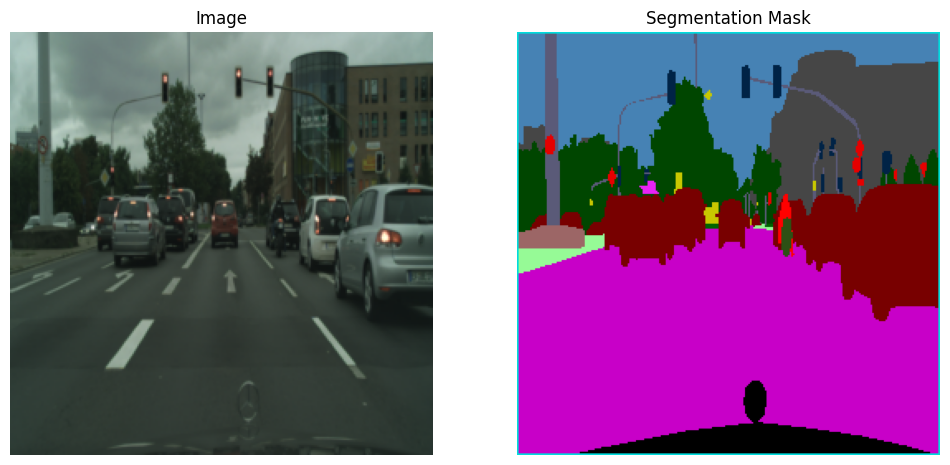

Sample id: 1061


In [ ]:
import random
dataset = MyDataset(os.path.join(electraawais_cityscape_dataset_path, "Cityscape Dataset/leftImg8bit/train"),
                          os.path.join(electraawais_cityscape_dataset_path, "Fine Annotations/gtFine/train"))
id = random.randint(0, len(dataset)-1)  # chọn ngẫu nhiên
features, labels = dataset[id]

img = features['image']  # (C,H,W)
mask = labels['segmentation']  # (num_classes,H,W) hoặc (H,W)
print(mask.shape)
print(img.shape)
# Nếu mask là one-hot, chuyển về class index
if mask.ndim == 3:
    mask_idx = torch.argmax(mask, dim=0)
else:
    mask_idx = mask

# Lấy các class có trong mask
classes = torch.unique(mask_idx)
print("Classes in mask:", classes)

# Hiển thị ảnh và mask
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(img.permute(1,2,0))
plt.title("Image")
plt.axis('off')

plt.subplot(122)
plt.imshow(Color(mask_idx))  # dùng colormap để phân biệt class
plt.title("Segmentation Mask")
plt.axis('off')
plt.show()

print("Sample id:", id)

<div class="markdown-google-sans">
  <h3>Đoạn code dùng để convert ảnh sau khi đã chuẩn hoá thành ảnh ban đầu</h3>
</div>

In [ ]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        Returns:
            Tensor: Normalized image.
        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
            # The normalize code -> t.sub_(m).div_(s)
        return tensor

unorm = UnNormalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

<div class="markdown-google-sans">
  <h3>Kiểm tra 1 cặp ảnh đầu vào và ảnh kết quả phân vùng trước khi đưa vào mô hình training</h3>
</div>

In [ ]:
# train_dataset = PascalVOCSearchDataset(image_set="train", download=True, transform=train_transform)
# test_dataset = PascalVOCSearchDataset(image_set="val", download=False, transform=test_trainsform)
train_dataset = MyDataset(os.path.join(electraawais_cityscape_dataset_path, "Cityscape Dataset/leftImg8bit/train"),
                          os.path.join(electraawais_cityscape_dataset_path, "Fine Annotations/gtFine/train"),
                            transform=train_transform)
val_dataset = MyDataset(os.path.join(electraawais_cityscape_dataset_path, "Cityscape Dataset/leftImg8bit/val"),
                          os.path.join(electraawais_cityscape_dataset_path, "Fine Annotations/gtFine/val"),
                          transform=test_transform)

Train len: 2975
Val len: 500
torch.Size([256, 256])
torch.Size([3, 256, 256])
Classes in mask: tensor([ 0,  1,  3,  4,  6,  7,  8, 10, 11, 12, 13, 17, 19, 20, 21, 23, 24, 25,
        26, 27, 28, 33])


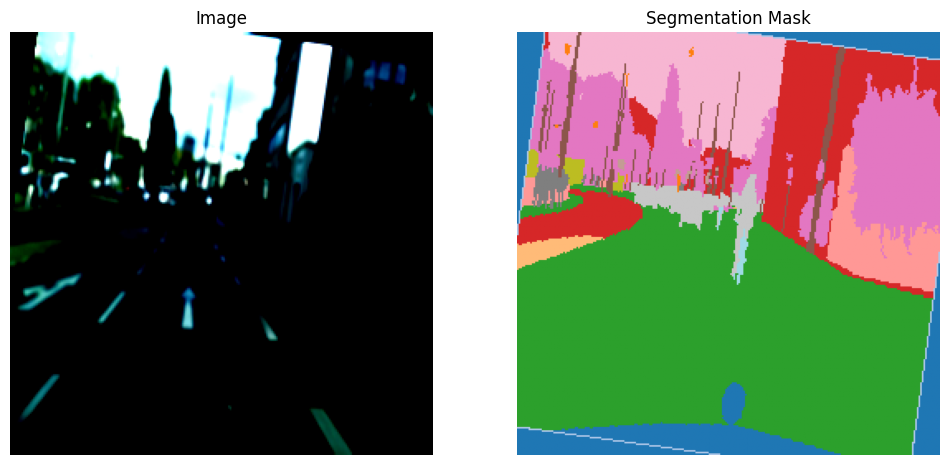

Sample id: 821
torch.Size([256, 256])


In [ ]:
print("Train len: {}".format(train_dataset.__len__()))
print("Val len: {}".format(val_dataset.__len__()))
id = random.randint(0, len(train_dataset)-1)  # chọn ngẫu nhiên
features, labels = train_dataset[id]

img = features['image']  # (C,H,W)
mask = labels['segmentation']  # (num_classes,H,W) hoặc (H,W)
print(mask.shape)
print(img.shape)
# Nếu mask là one-hot, chuyển về class index
if mask.ndim == 3:
    mask_idx = torch.argmax(mask, dim=0)
else:
    mask_idx = mask

# Lấy các class có trong mask
classes = torch.unique(mask_idx)
print("Classes in mask:", classes)

# Hiển thị ảnh và mask
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(img.permute(1,2,0))
plt.title("Image")
plt.axis('off')

plt.subplot(122)
plt.imshow(mask_idx, cmap='tab20')  # dùng colormap để phân biệt class
plt.title("Segmentation Mask")
plt.axis('off')
plt.show()

print("Sample id:", id)
print(mask.shape)

In [ ]:
class EarlyStopping():
    """
    Stops training when loss stops decreasing in a PyTorch module.
    """
    def __init__(self, patience:int = 6, min_delta: float = 0, weights_path: str = 'weights.pt'):
        """
        :param patience: number of epochs of non-decreasing loss before stopping
        :param min_delta: minimum difference between best and new loss that is considered
            an improvement
        :paran weights_path: Path to the file that should store the model's weights
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.weights_path = weights_path

    def __call__(self, val_loss: float, model: torch.nn.Module):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.weights_path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

    def load_weights(self, model: torch.nn.Module):
        """
        Loads weights of the best model.
        :param model: model to which the weigths should be loaded
        """
        return model.load_state_dict(torch.load(self.weights_path))

<div class="markdown-google-sans">
  <h3>Tạo AverageMeter</h3>
</div>
AverageMeter có nhiệm vụ lưu lại giá trị trung bình của độ chính xác, giá trị hàm loss, ... trong suốt quá trình training. Tham khảo thêm: https://discuss.pytorch.org/t/meaning-of-parameters/10655

In [ ]:
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0


    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


In [ ]:
class ArrayMeter:
    def __init__(self,classes):
        self.classes = classes
        self.reset()

    def reset(self):
        self.Array = np.zeros(len(self.classes),dtype = np.float64)
        self.count = 0

    def update(self,values):
        self.Array += values
        self.count += 1
        self.mArray = self.Array/self.count


<div class="markdown-google-sans">
  <h3>Lập trình hàm tính toán độ chính xác</h3>
</div>

In [ ]:
#accuracy fn
def accuracy_function(preds, targets):
    preds_flat = preds.flatten()
    targets_flat = targets.flatten()
    acc = torch.sum(preds_flat == targets_flat)
    return acc/targets_flat.shape[0]

In [ ]:

def CalcIntersectUnion(pred, target, classes):
    """
    pred: tensor (B, C, H, W) logits or one-hot
    target: tensor (B, C, H, W) one-hot
    classes: list of class indices
    Returns: intersections, unions, pred+target counts (all lists of length len(classes))
    """
    # Get predicted class per pixel
    # pred_label = torch.argmax(pred, dim=1)  # B x H x W
    # target_label = torch.argmax(target, dim=1)  # B x H x W
    pred_label = pred.long()
    target_label = target.long()

    intersections = []
    unions = []
    predandtars = []
    for cls in classes:
        pred_cls = (pred_label == cls)
        target_cls = (target == cls)

        intersection = (pred_cls & target_cls).sum().item()
        union = (pred_cls | target_cls).sum().item()
        pred_sum = pred_cls.sum().item()
        target_sum = target_cls.sum().item()

        intersection = intersection if intersection != 0 else 1e-7
        union = union if union != 0 else 1e-7
        target_sum = target_sum if pred_sum + target_sum != 0 else 1e-7

        intersections.append(intersection)
        unions.append(union)
        predandtars.append(pred_sum + target_sum)


    return intersections, unions, predandtars

## Criteria

In [ ]:
def intersectionAndUnionGPU(output, target, K, ignore_index=255):
    # 'K' classes, output and target sizes are N or N * L or N * H * W, each value in range 0 to K - 1.
    assert (output.dim() in [1, 2, 3])
    assert output.shape == target.shape
    output = output.view(-1)
    target = target.view(-1)
    output[target == ignore_index] = ignore_index
    intersection = output[output == target]
    area_intersection = torch.histc(intersection, bins=K, min=0, max=K-1)
    area_output = torch.histc(output, bins=K, min=0, max=K-1)
    area_target = torch.histc(target, bins=K, min=0, max=K-1)
    area_union = area_output + area_target - area_intersection
    return area_intersection, area_union, area_target

In [ ]:
#device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
Classes = [7,8,11,14,17,19,21,22,23,24,25,26,28,32,33]
#load data
batch_size = 8
n_workers = 0
print("num_workers =", n_workers)
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=n_workers)
testloader = torch.utils.data.DataLoader(val_dataset, batch_size=2,
                                          shuffle=False, num_workers=n_workers)

data_classes = 33
#model

#loss
# criterion = nn.CrossEntropyLoss()

# DiceLoss = smp.losses.DiceLoss(mode="multiclass",classes=None)
# IoULoss = smp.losses.JaccardLoss(mode="multiclass",classes=None)


# n_eps = 60

#meter
train_loss_meter = AverageMeter()
train_intersection_meter = AverageMeter()
train_union_meter = AverageMeter()
train_target_meter = AverageMeter()
train_acc_meter = AverageMeter()
train_iou_meter_perclass = AverageMeter()


val_loss_meter = AverageMeter()
val_intersection_meter = AverageMeter()
val_union_meter = AverageMeter()
val_target_meter = AverageMeter()
val_acc_meter = AverageMeter()
val_Intperclass = ArrayMeter(Classes)
val_Uniperclass = ArrayMeter(Classes)
val_PredandTar = ArrayMeter(Classes)

time_execute_GPU = AverageMeter()
time_execute_CPU = AverageMeter()

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_IoU, train_Dice = [],[]

early_stopping = EarlyStopping(patience=30)

cuda
num_workers = 0


## Loss

In [ ]:
import torch
import torch.nn.functional as F

import torch
import torch.nn.functional as F

def multi_class_separation_loss(
    features,
    gt_mask,
    classes,              # list / set các class cần ưu tiên
    epsilon=1e-2,
    min_samples=5,
    weight=4            # trọng số cho các class trong "classes"
):
    """
    Multi-class feature separation loss with class weighting.

    Args:
        features (Tensor): (B, C, H, W)
        gt_mask (Tensor): (B, K, H_gt, W_gt)
        classes (list[int] or set[int]): class indices được tăng trọng số
        epsilon (float): numerical stability
        min_samples (int): minimum pixels per class
        weight (float): weight multiplier for selected classes

    Returns:
        Tensor: scalar loss
    """

    B, C, H, W = features.shape
    K = gt_mask.size(1)

    # Resize gt mask to feature size
    gt_mask = F.interpolate(gt_mask, size=(H, W), mode='area')

    total_loss = 0.0
    total_weight = 0.0

    for cls in range(K):
        mask_c = gt_mask[:, cls].unsqueeze(1)
        mask_not_c = 1.0 - mask_c

        n_c = mask_c.sum((0, 2, 3), keepdim=True)
        n_not_c = mask_not_c.sum((0, 2, 3), keepdim=True)

        if n_c < min_samples or n_not_c < min_samples:
            continue

        feat_c = features * mask_c
        feat_not_c = features * mask_not_c

        mean_c = feat_c.sum((0, 2, 3), keepdim=True) / n_c

        var_c = ((feat_c - mean_c * mask_c) ** 2).sum(
            (0, 2, 3), keepdim=True
        ) / n_c

        dist_not_c = ((feat_not_c - mean_c * mask_not_c) ** 2).sum(
            (0, 2, 3), keepdim=True
        )

        loss_c = n_not_c * var_c / (dist_not_c + epsilon)
        loss_c = loss_c.mean()

        # Áp dụng trọng số
        if cls in classes:
            total_loss += weight * loss_c
            total_weight += weight
        else:
            total_loss += loss_c
            total_weight += 1.0

    if total_weight == 0:
        return torch.tensor(0., device=features.device)

    return total_loss / total_weight



def focal_loss(logits, labels, gamma=2.0, alpha=4.0, target_scale='labels'):
    """Focal loss of the segmentation output `logits` and ground truth `labels`."""

    epsilon = 1.e-9

    if target_scale == 'logits':
        # Resize one-hot labels to match the logits scale
        logits_size = (logits.size(2), logits.size(3))
        labels = F.interpolate(labels, size=logits_size, mode='area')
    elif target_scale == 'labels':
        # Resize network output to match the label size
        labels_size = (labels.size(2), labels.size(3))
        logits = TF.resize(logits, labels_size, interpolation=InterpolationMode.BILINEAR)
    else:
        raise ValueError('Invalid value for target_scale: %s' % target_scale)

    logits_sm = torch.softmax(logits, 1)

    # Focal loss
    fl = -labels * torch.log(logits_sm + epsilon) * (1. - logits_sm) ** gamma
    fl = fl.sum(1) # Sum focal loss along channel dimension

    # Return mean of the focal loss along spatial and batch dimensions
    return fl.mean()

In [ ]:
def criterion(y_hat_aux,y_hat_out,gt_mask,classes):
    return 0.5*multi_class_separation_loss(y_hat_aux,gt_mask,classes)+0.5*focal_loss(y_hat_out, gt_mask, target_scale='logits')


## Model

In [ ]:
sys.path.append("/content/eWaSR2")

In [ ]:
from wasr.decoders import IMUDecoder
from wasr.utils import IntermediateLayerGetter
from segmentation_models_pytorch.encoders import get_encoder
from collections import OrderedDict
from torchvision.models.resnet import resnet50
class wasr_resnet50_imu(nn.Module):
    def __init__(self,num_classes):
        super(wasr_resnet50_imu,self).__init__()

        self.imu = True
        backbone = resnet50(pretrained=True, replace_stride_with_dilation=[False, True, True])
        return_layers = {
            'layer4': 'out',
            'layer1': 'skip1',
            'layer2': 'skip2',
            'layer3': 'aux'
        }
        backbone = IntermediateLayerGetter(backbone, return_layers=return_layers)
        decoder = IMUDecoder(num_classes)
        self.backbone = backbone
        self.decoder = decoder

    def forward(self, x):
        features = self.backbone(x['image'])
        # print(features['out'].shape)
        # print(features['aux'].shape)
        # print(features['skip2'].shape)
        # print(features['skip1'].shape)
        features['imu_mask'] = x['imu_mask'].float().unsqueeze(1)
        features = (features['out'], features['aux'], features['skip2'], features['skip1'], features['imu_mask'])
        aux = features[1]
        x = self.decoder(*features)

        # # Return segmentation map and aux feature map
        output = OrderedDict([
            ('out', x),
            ('aux', aux)
        ])

        return output

## Load model

In [ ]:
# model = wasr_resnet50_imu(num_classes = Num_classes)


In [ ]:
# if base_load_path is not None:
#     state_dict = torch.load(base_load_path,
#                            map_location=torch.device('cpu'))

#     # Load the state dictionary into the model
#     model.load_state_dict(state_dict)
#     print("Model loaded successfully!")

In [ ]:
# torch.save(model,"WaSRResNet50imuCityscapes.pth")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if prune_load_path is not None:
    model = torch.load(prune_load_path,map_location=torch.device('cpu'),weights_only=False)

    # Load the state dictionary into the model
    print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
print(device)

cuda


<div class="markdown-google-sans">
  <h3>Training thôi ...</h3>
</div>
Tham khảo thêm cách viết code training trong PyTorch: https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

In [ ]:
def one_hot(gt_mask,Num_classes):
    #mask (B, H, W) -> (B, K, H, W)
    B, H, W = gt_mask.shape

    gt_mask = gt_mask.long()
    gt_mask = F.one_hot(gt_mask, num_classes=Num_classes)   # (B, H, W, K)
    gt_mask = gt_mask.permute(0, 3, 1, 2).float() # (B, K, H, W)
    return gt_mask

## Prune

In [ ]:
///

SyntaxError: invalid syntax (2387118227.py, line 1)

In [ ]:
print(model)

In [ ]:
# import torch_pruning as tp
# from copy import deepcopy
# m = deepcopy(model)
# m.eval()
# m.to(device)
# img = torch.randn(1,3,256,256).to(device)
# imu_mask = torch.zeros((1, 1, 1)).bool().to(device)
# example_inputs = {'image': img,'imu_mask' : imu_mask}
# # pred = model({'image': img,'imu_mask' : imu_mask})
# # 1. Importance criterion, here we calculate the L2 Norm of grouped weights as the importance score
# imp = tp.importance.GroupMagnitudeImportance(p=2)
# # 2. Initialize a pruner with the model and the importance criterion
# ignored_layers = []
# for name, module in m.named_modules():
#     if isinstance(module, torch.nn.Conv2d):
#         # 1. Bảo vệ đầu ra (Segmentation Head)
#         if module.out_channels == 34:
#             ignored_layers.append(module)
#         # 2. Bảo vệ các điểm Fusion IMU (số channel lẻ)
#         if module.in_channels in [513, 2049, 2081, 1281] or module.out_channels in [513, 2049, 2081, 1281]:
#             ignored_layers.append(module)
# # ignored_layers.append(last_layer) # DO NOT prune the final classifier!
# # print(ignored_layers)
# pruner = tp.pruner.BasePruner( # We can always choose BasePruner if sparse training is not required.
#     m,
#     example_inputs,
#     importance=imp,
#     pruning_ratio=0.75, # remove 50% channels, ResNet18 = {64, 128, 256, 512} => ResNet18_Half = {32, 64, 128, 256}
#     # pruning_ratio_dict = {model.conv1: 0.2, model.layer2: 0.8}, # customized pruning ratios for layers or blocks
#     isomorphic=True, # enable isomorphic pruning to improve global ranking
#     global_pruning=True, # global pruning
#     ignored_layers=ignored_layers,
#     round_to=8, # It's recommended to round dims/channels to 4x or 8x for acceleration. Please see: https://docs.nvidia.com/deeplearning/performance/dl-performance-convolutional/index.html
# )
# base_macs, base_nparams = tp.utils.count_ops_and_params(m, example_inputs)
# tp.utils.print_tool.before_pruning(m) # or print(model)
# pruner.step()
# # for group in pruner.step(interactive=True):
# #     print(group)
# tp.utils.print_tool.after_pruning(m) # or print(model), this util will show the difference before and after pruning
# macs, nparams = tp.utils.count_ops_and_params(m, example_inputs)
# print(f"MACs: {base_macs/1e9} G -> {macs/1e9} G, #Params: {base_nparams/1e6} M -> {nparams/1e6} M")

## Quantization

In [ ]:
print(device)

cuda


In [ ]:
import onnx
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType
import copy
model_fp32 = copy.deepcopy(model)
device = torch.device("cpu")
# 1. Tạo một lớp Wrapper để "phẳng hóa" đầu vào
class EwaSR_ONNX_Wrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, image, imu_mask):
        # Đóng gói lại thành Dictionary đúng cấu trúc mô hình e-WaSR yêu cầu bên trong
        return self.model({"image": image, "imu_mask": imu_mask})

# 2. Chuẩn bị mô hình và dữ liệu mẫu
model_fp32.eval()
wrapper_model = EwaSR_ONNX_Wrapper(model_fp32).to(device)

# Dữ liệu mẫu dạng Tensor riêng biệt (không dùng dict ở đây)
dummy_image = torch.randn(1, 3, 256, 256).to(device)
dummy_imu = torch.zeros((1, 1, 1)).float().to(device) # Đổi .bool() thành .float() để an toàn cho Quantization

# 3. Export - Truyền vào một Tuple các Tensor
torch.onnx.export(
    wrapper_model,
    (dummy_image, dummy_imu), # 2 tham số riêng biệt
    f="{}_fp32.onnx".format(model_name),
    opset_version=13, # Khuyên dùng 13 để hỗ trợ tốt hơn cho PyTorch 2.x
    input_names=["image", "imu_mask"], # Tên cổng vào trong file ONNX
    output_names=["prediction"],
    dynamic_axes={
        "image": {0: "batch_size"},
        "imu_mask": {0: "batch_size"},
        "prediction": {0: "batch_size"}
    }
)

/tmp/ipykernel_1621/3798819979.py:22: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(
/tmp/ipykernel_1621/3798819979.py:22: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0327 16:18:37.890000 1621 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version

[torch.onnx] Obtain model graph for `EwaSR_ONNX_Wrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EwaSR_ONNX_Wrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch_size will not be used, since it shares the same shape constraints with another axis: batch_size.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:65: adapter_lookup: Assertion `false`

Applied 111 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"image"<FLOAT,[batch_size,3,256,256]>,
                %"imu_mask"<FLOAT,[batch_size,1,1]>
            ),
            outputs=(
                %"prediction"<FLOAT,[batch_size,34,64,64]>,
                %"relu_39"<FLOAT,[batch_size,768,32,32]>
            ),
            initializers=(
                %"model.decoder.aspp1.convs.0.0.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"model.decoder.aspp1.convs.1.0.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"model.decoder.aspp1.convs.2.0.bias"<FLOAT,[32]>{TorchTensor(...)},
                %"model.decoder.ffm1.conv2.bias"<FLOAT,[832]>{TorchTensor(...)},
                %"model.decoder.arm2.0.conv1.bias

In [ ]:
import logging
logging.basicConfig(level=logging.INFO)
class MyDataReader(CalibrationDataReader):
    def __init__(self, dataloader, limit=100):
        # Chúng ta chỉ lấy iter từ dataloader, không nạp dữ liệu vào RAM ở đây
        self.dataloader_iter = iter(dataloader)
        self.limit = limit # Chỉ cần khoảng 100 mẫu để calibrate
        self.counter = 0

    def get_next(self):
        if self.counter >= self.limit:
            return None  # Dừng lại khi đủ số lượng mẫu cần thiết

        try:
            data, _ = next(self.dataloader_iter)
            self.counter += 1

            # Đảm bảo key khớp với input_names trong file ONNX
            # Giả sử dataloader trả về dict có key 'image' và 'imu_mask'
            return {
                "image": data['image'].cpu().numpy(),
                "imu_mask": data['imu_mask'].cpu().numpy().astype(np.float32)
            }
        except StopIteration:
            return None

# Khởi tạo reader với giới hạn 100 ảnh
dr = MyDataReader(testloader, limit=10)

quantize_static(
    "{}_fp32.onnx".format(model_name),
    "{}_quantized_final.onnx".format(model_name),
    dr,
    quant_format=QuantType.QInt8,
    op_types_to_quantize=['Conv', 'MatMul'],  # ← chỉ quantize những op này thay vì toàn bộ graph
)

In [ ]:
import onnxruntime as ort
sess = ort.InferenceSession(quantized_load_path.format(model_name))
print([i.name for i in sess.get_inputs()])

['image', 'imu_mask']


In [ ]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession("{}_quantized_final.onnx".format(model_name), providers=['CPUExecutionProvider'])

# Lấy tên input/output từ session
input_image_name = session.get_inputs()[0].name
input_imu_mask_name = session.get_inputs()[1].name
output_name = session.get_outputs()[0].name

print(f"Input image name: {input_image_name}")
print(f"Input IMU mask name: {input_imu_mask_name}")
print(f"Output name: {output_name}")
# Chuẩn bị dữ liệu
features, labels = val_dataset[0]

# QUAN TRỌNG:
# 1. Thêm chiều batch bằng unsqueeze(0)
# 2. Chuyển sang Numpy bằng .numpy()
# 3. Đảm bảo kiểu dữ liệu khớp (float32 cho ảnh, float32 hoặc int cho mask)
input_image = features['image'].unsqueeze(0).numpy()
input_imu_mask = features['imu_mask'].unsqueeze(0).numpy().astype(np.float32)

# Chạy Inference
outputs = session.run([output_name], {
    input_image_name: input_image,
    input_imu_mask_name: input_imu_mask
})
print("✨ Success! Inference completed.")
print(f"Output shape: {outputs[0].shape}")

Input image name: image
Input IMU mask name: imu_mask
Output name: prediction
✨ Success! Inference completed.
Output shape: (1, 34, 64, 64)


## Train

In [ ]:
# model = model.to(device)
# for ep in range(1, 1+n_eps):
#     train_loss_meter.reset()
#     train_acc_meter.reset()
#     train_intersection_meter.reset()
#     train_union_meter.reset()
#     train_target_meter.reset()
#     for batch_id, (x, y) in enumerate(tqdm(trainloader), start=1):
#         model.train()
#         optimizer.zero_grad()
#         x = {k: v.to(torch.float32).to(device) for k, v in x.items()}
#         y = {k: v.to(torch.int64).to(device) for k, v in y.items()}
#         n = x['image'].shape[0]
#         y_hat = model(x)
#         # print(y_hat['out'].shape)
#         # print(y['segmentation'].shape)
#         # print(y_hat['out'].shape[1])
#         gt_mask_onehot = one_hot(y['segmentation'],Num_classes)
#         loss = criterion(y_hat_aux=y_hat['aux'],y_hat_out=y_hat['out'],gt_mask=gt_mask_onehot,classes = Classes)
#         # loss = 0.5*multi_class_separation_loss(y_hat['aux'],gt_mask_onehot,classes = Classes)+0.5*focal_loss(y_hat['out'],gt_mask_onehot, target_scale='logits')
#         loss.backward()
#         optimizer.step()
#         with torch.inference_mode():
#             y['segmentation'] = TF.resize(y['segmentation'],(64, 64),interpolation=InterpolationMode.NEAREST)
#             y_hat_mask = y_hat['out'].argmax(dim=1).squeeze() # (B, C, H, W) -> (B, 1, H, W) -> (B, H, W)
#             # y_hat_mask = y_hat_mask.argmax(dim=0).squeeze()
#             # print(y_hat_mask.shape)
#             # print(y['segmentation'].shape)
#             y_mask = y['segmentation'].long()
#             # y_mask = TF.resize(y_mask,(64, 64),interpolation=InterpolationMode.NEAREST)
#             # y_mask = y_mask.argmax(dim=0).squeeze()

#             # Int, Uni, PredandTar = CalcIntersectUnion(y_hat_mask, y_mask, Classes)

#             intersection, union, target = intersectionAndUnionGPU(y_hat_mask.float(), y_mask.float(),data_classes)


#             train_loss_meter.update(loss.item(), n)
#             train_intersection_meter.update(intersection)
#             train_union_meter.update(union)
#             train_target_meter.update(target)
#             train_accuracy = accuracy_function(y_hat_mask, y_mask)
#             train_acc_meter.update(train_accuracy.item(), n)


#     with torch.inference_mode():
#         iou_class = train_intersection_meter.sum / (train_union_meter.sum + 1e-10) #vector 21D
#         dice_class = (2 * train_intersection_meter.sum) / (train_intersection_meter.sum + train_union_meter.sum + 1e-10) #vector 21D

#         mIoU = torch.mean(iou_class) #mean vector 21D
#         mDice = torch.mean(dice_class) #mean vector 21D
#     print("EP {}, accuracy = {} train loss = {} IoU = {}, dice = {}".format(ep,train_acc_meter.avg, train_loss_meter.avg, mIoU, mDice))

#     if early_stopping(train_loss_meter.avg, model):
#         early_stopping.load_weights(model)
#         torch.save(model.state_dict(), save_path)
#         break

#     torch.save(model.state_dict(), save_path)
#     train_losses.append(train_loss_meter.avg)
#     train_accuracies.append(train_acc_meter.avg)
#     train_IoU.append(mIoU)
#     train_Dice.append(mDice)




In [ ]:
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
# plt.plot(val_lossed, label = 'Val Loss')
plt.title('Loss during Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy')
# plt.plot(val_accuracies, label = 'Val Accuracy')
plt.title('Accuracy during Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

<div class="markdown-google-sans">
  <h3>Viết code hiển thị kết quả dự đoán</h3>
</div>

In [ ]:
def validate():
    val_acc_meter.reset()
    val_intersection_meter.reset()
    val_union_meter.reset()
    val_target_meter.reset()
    val_Intperclass.reset()
    val_Uniperclass.reset()
    val_PredandTar.reset()
    time_execute_GPU.reset()

    for batch_id, (x, y) in enumerate(tqdm(testloader), start=1):
        n = x['image'].shape[0]

        input_image = x['image'].numpy()
        input_imu_mask = x['imu_mask'].numpy().astype(np.float32) # Ensure correct dtype for ONNX input
        start = time.time()
        with torch.inference_mode():
            outputs = session.run([output_name], {
                input_image_name: input_image,
                input_imu_mask_name: input_imu_mask
                })
        end = time.time()

        # outputs[0] is a NumPy array, convert to PyTorch tensor for argmax
        onnx_output_tensor = torch.from_numpy(outputs[0])
        # Get predicted class indices (B, H, W)
        y_hat_mask_predicted = onnx_output_tensor.argmax(dim=1)

        with torch.inference_mode():
            # Resize ground truth mask to match model output resolution
            y_mask_gt = TF.resize(y['segmentation'], (64, 64), interpolation=InterpolationMode.NEAREST)
            y_mask_gt = y_mask_gt.long() # Ensure GT mask is long type

            # Accuracy calculation
            accuracy = accuracy_function(y_hat_mask_predicted, y_mask_gt)

            # Intersection and Union calculations
            Int, Uni, PredandTar = CalcIntersectUnion(y_hat_mask_predicted, y_mask_gt, Classes)
            intersection, union, target = intersectionAndUnionGPU(y_hat_mask_predicted.float(), y_mask_gt.float(), Num_classes) # Use Num_classes for consistency

            val_intersection_meter.update(intersection)
            val_union_meter.update(union)
            val_acc_meter.update(accuracy.item(),n)
            val_target_meter.update(target)
            val_Intperclass.update(Int)
            val_Uniperclass.update(Uni)
            val_PredandTar.update(PredandTar)
            time_execute_GPU.update(end-start)


    with torch.no_grad():
        iou_class = val_intersection_meter.sum / (val_union_meter.sum + 1e-10)
        dice_class = (2 * val_intersection_meter.sum) / (val_intersection_meter.sum + val_union_meter.sum + 1e-10)

        mIoU = torch.mean(iou_class)
        mDice = torch.mean(dice_class)

    print("val loss = {}, accuracy = {}, IoU = {}, dice = {}".format(
        val_loss_meter.avg, val_acc_meter.avg, mIoU, mDice
    ))
    IoU = np.zeros(len(Classes),dtype = np.float64) # Use Classes for length
    IoU = val_Intperclass.Array/val_Uniperclass.Array
    Dice = np.zeros(len(Classes),dtype = np.float64) # Use Classes for length
    Dice = 2*val_Intperclass.Array/val_PredandTar.Array
    for i,class_id in enumerate(Classes):
        print("class: {} \t mIoU: {} \t mDice: {}".format(names[class_id],IoU[i],Dice[i]))

    with open("Names.txt", "w", encoding="utf-8") as f:
        pass # Clears file
    with open("IoU.txt", "w", encoding="utf-8") as f:
        pass # Clears file
    with open("Dice.txt", "w", encoding="utf-8") as f:
        pass # Clears file

    for i,class_id in enumerate(Classes):
        with open("Names.txt", "a", encoding="utf-8") as f:
            f.write("{} \t ".format(names[class_id]))
    for i,class_id in enumerate(Classes):
        with open("IoU.txt", "a", encoding="utf-8") as f:
            f.write("{:.2f} \t ".format(IoU[i]*100))
    for i,class_id in enumerate(Classes):
        with open("Dice.txt", "a", encoding="utf-8") as f:
            f.write("{:.2f} \t ".format(Dice[i]*100))
    print("GPU mean execute time: {}".format(time_execute_GPU.avg))


In [ ]:
def add_batch_dim(sample):
    return {k: v.unsqueeze(0) for k, v in sample.items()}

In [ ]:
def validate_CPU():
    model.eval()
    model.to("cpu")
    time_execute_CPU.reset()
    for i in range(0,3):
        with torch.no_grad():
            x, y = val_dataset.__getitem__(i)
            start = time.time()
            y_predict = model(add_batch_dim(x))
            end = time.time()
            time_execute_CPU.update(end-start)
    print("CPU mean execute time: {}".format(time_execute_CPU.avg))
    model.to(device)




In [ ]:
validate()

100%|██████████| 250/250 [13:19<00:00,  3.20s/it]

val loss = 0, accuracy = 0.81644580078125, IoU = 0.31679004430770874, dice = 0.417817622423172
class: road 	 mIoU: 0.8709340391453646 	 mDice: 0.931015226537359
class: sidewalk 	 mIoU: 0.570633591390289 	 mDice: 0.7266285332517594
class: building 	 mIoU: 0.7399255732870541 	 mDice: 0.8505255450545295
class: forward-faced sign 	 mIoU: 0.709677497086346 	 mDice: 0.8301888624421178
class: pole/fence 	 mIoU: 0.16768329166566362 	 mDice: 0.2872068015195775
class: traffic light 	 mIoU: 0.21810226036067312 	 mDice: 0.3581017261391653
class: tree 	 mIoU: 0.7643964889359424 	 mDice: 0.8664679324966266
class: grass 	 mIoU: 0.41959983295950093 	 mDice: 0.5911522718319712
class: sky 	 mIoU: 0.7452557550496542 	 mDice: 0.8540361524755906
class: pedestrian 	 mIoU: 0.4306672842177531 	 mDice: 0.60205092972143
class: biker 	 mIoU: 0.16609662645822293 	 mDice: 0.28487626719524495
class: car 	 mIoU: 0.7578096844442346 	 mDice: 0.8622203997987239
class: truck/bus 	 mIoU: 0.4121600677403483 	 mDice: 0.583

In [ ]:
# validate_CPU()

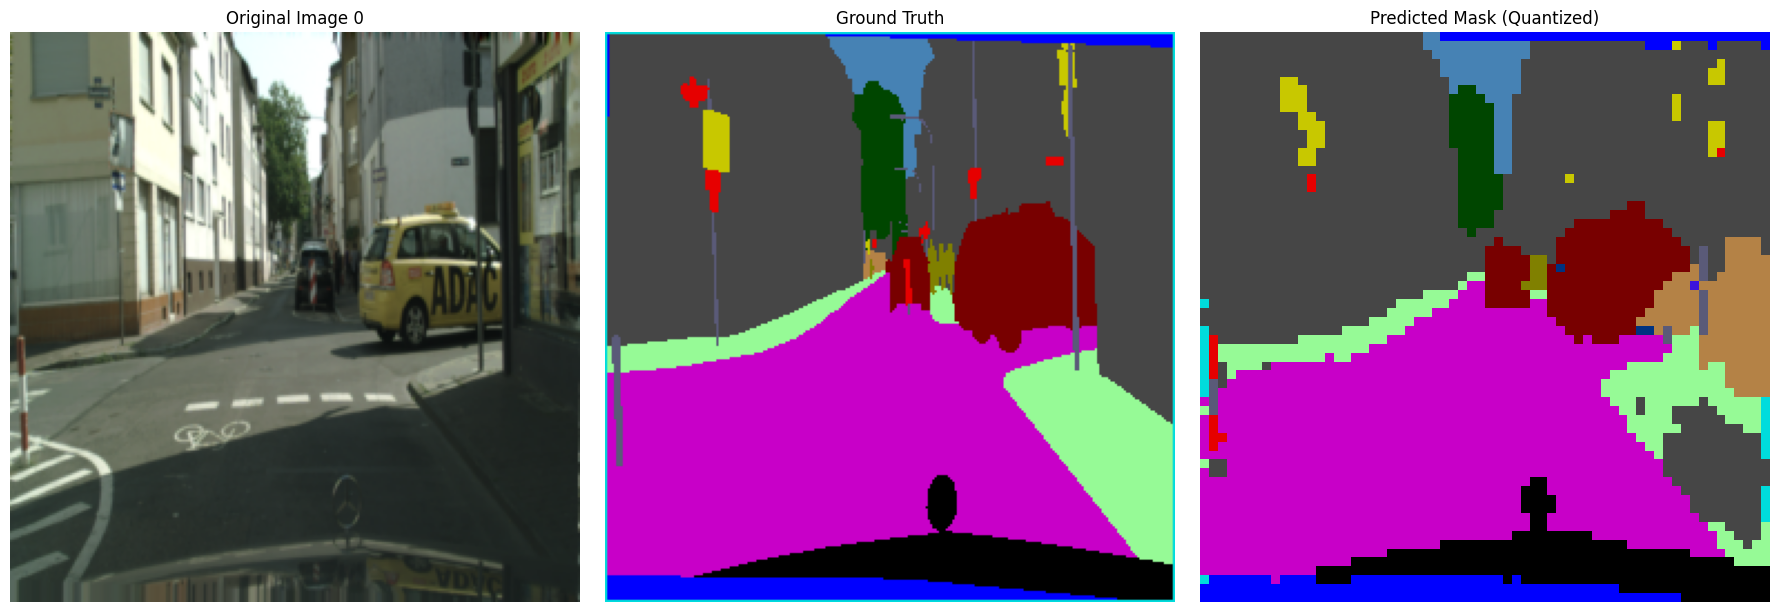

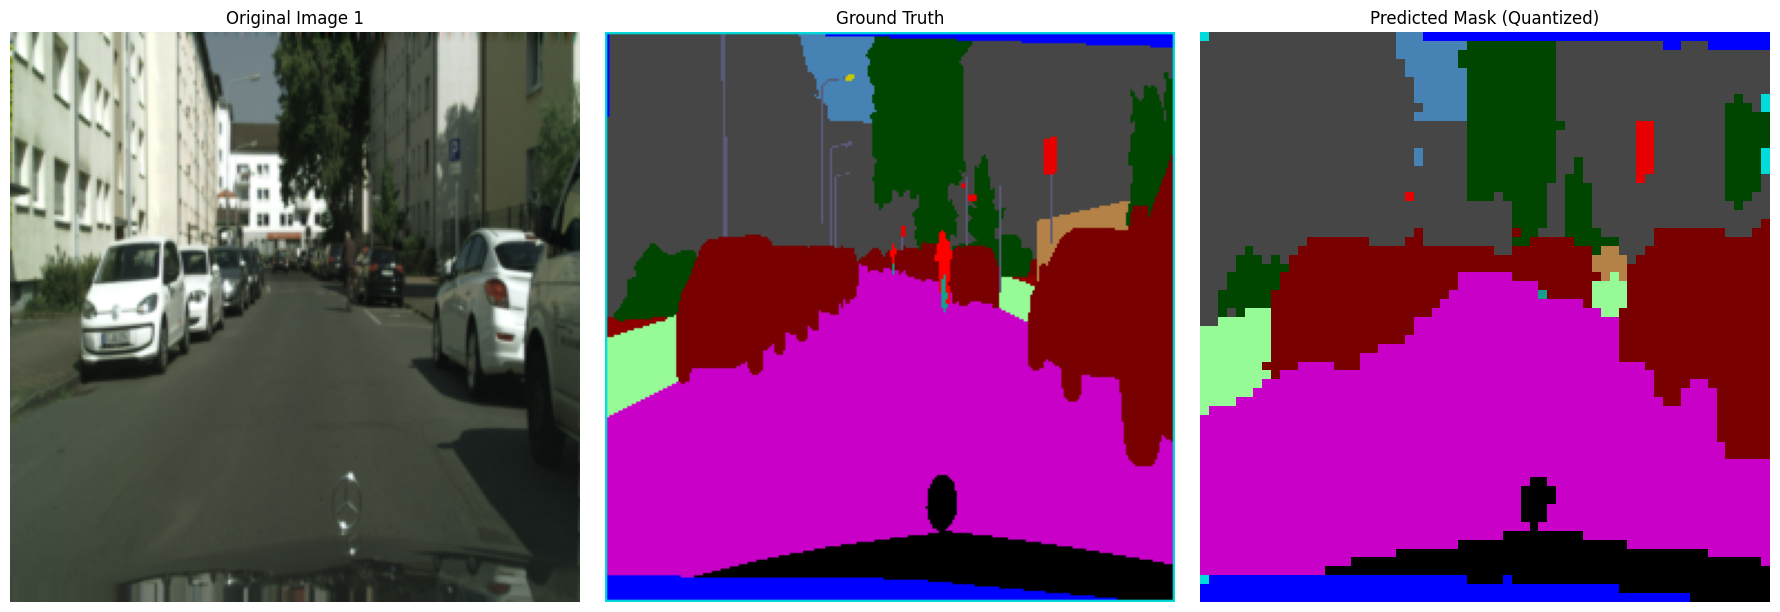

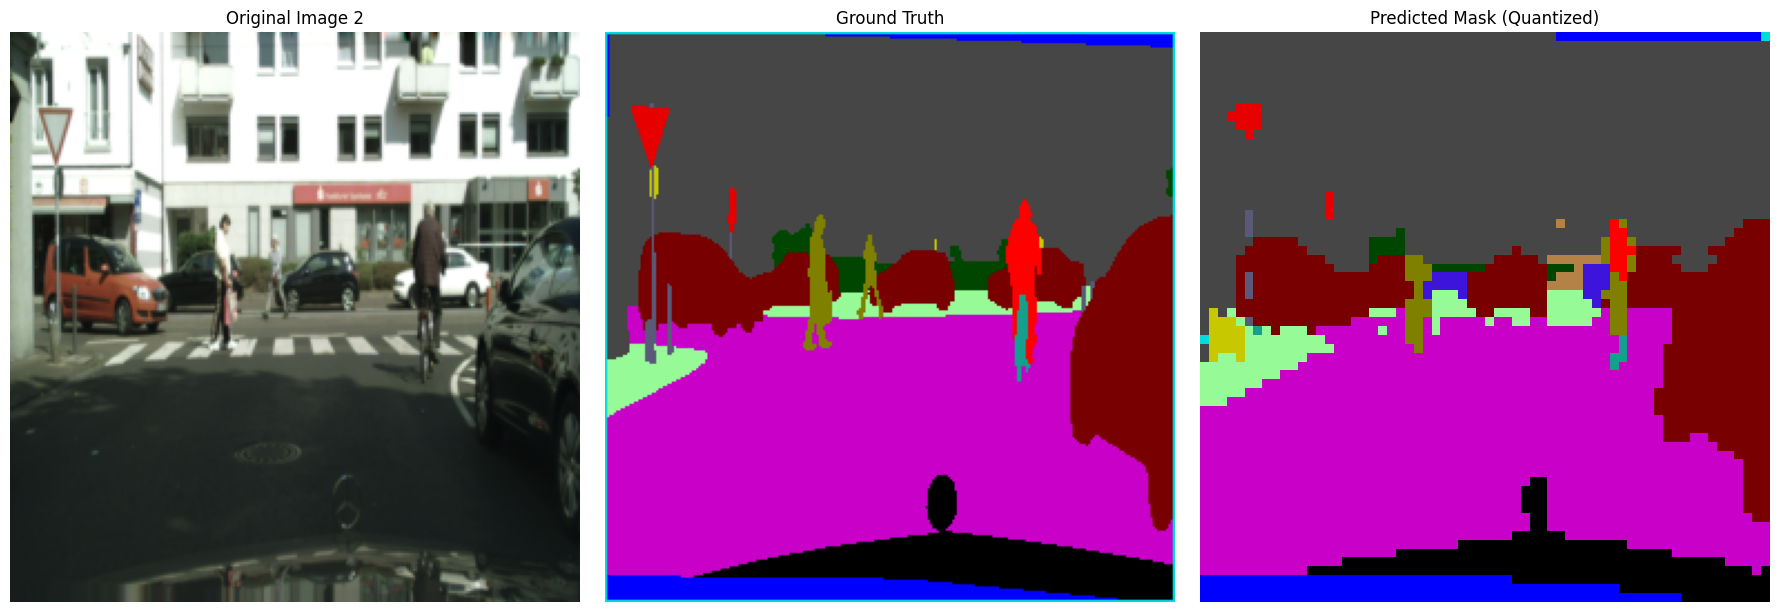

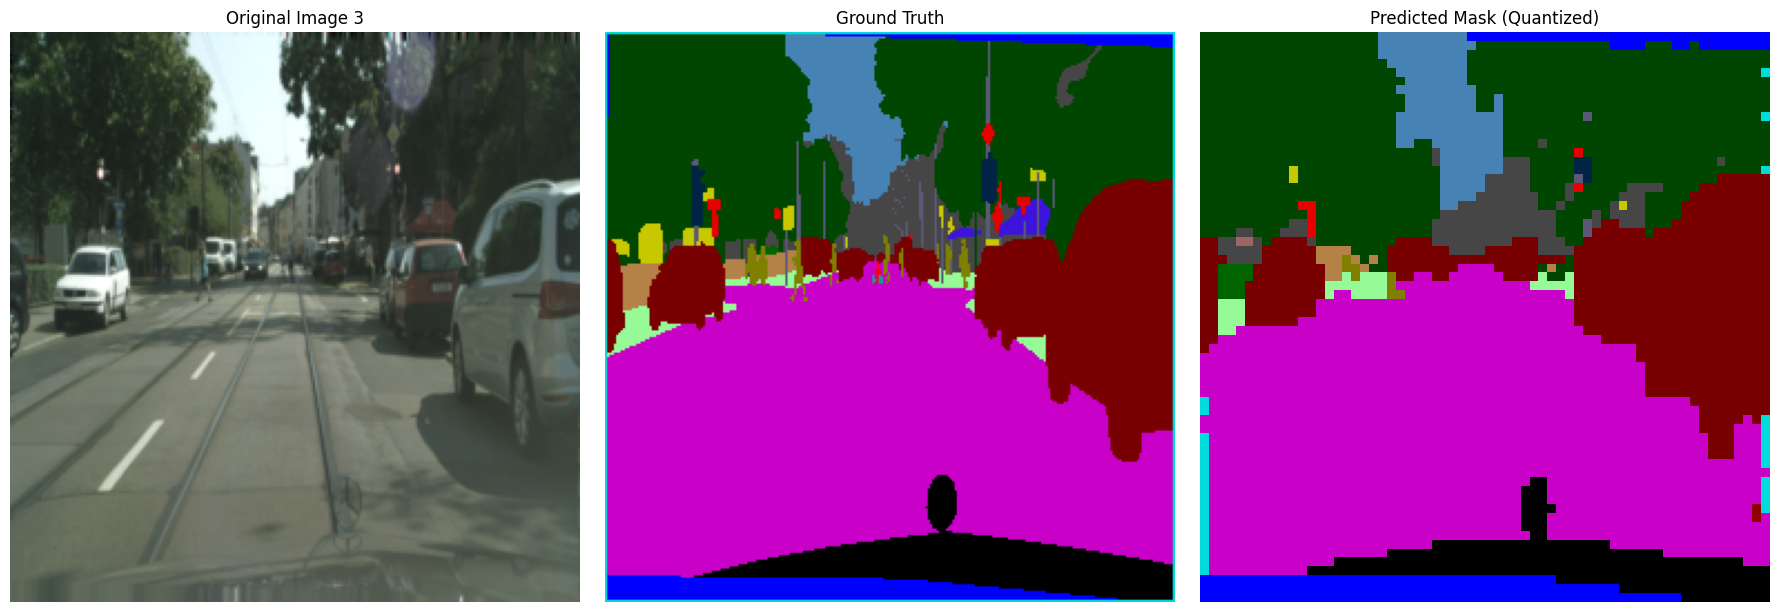

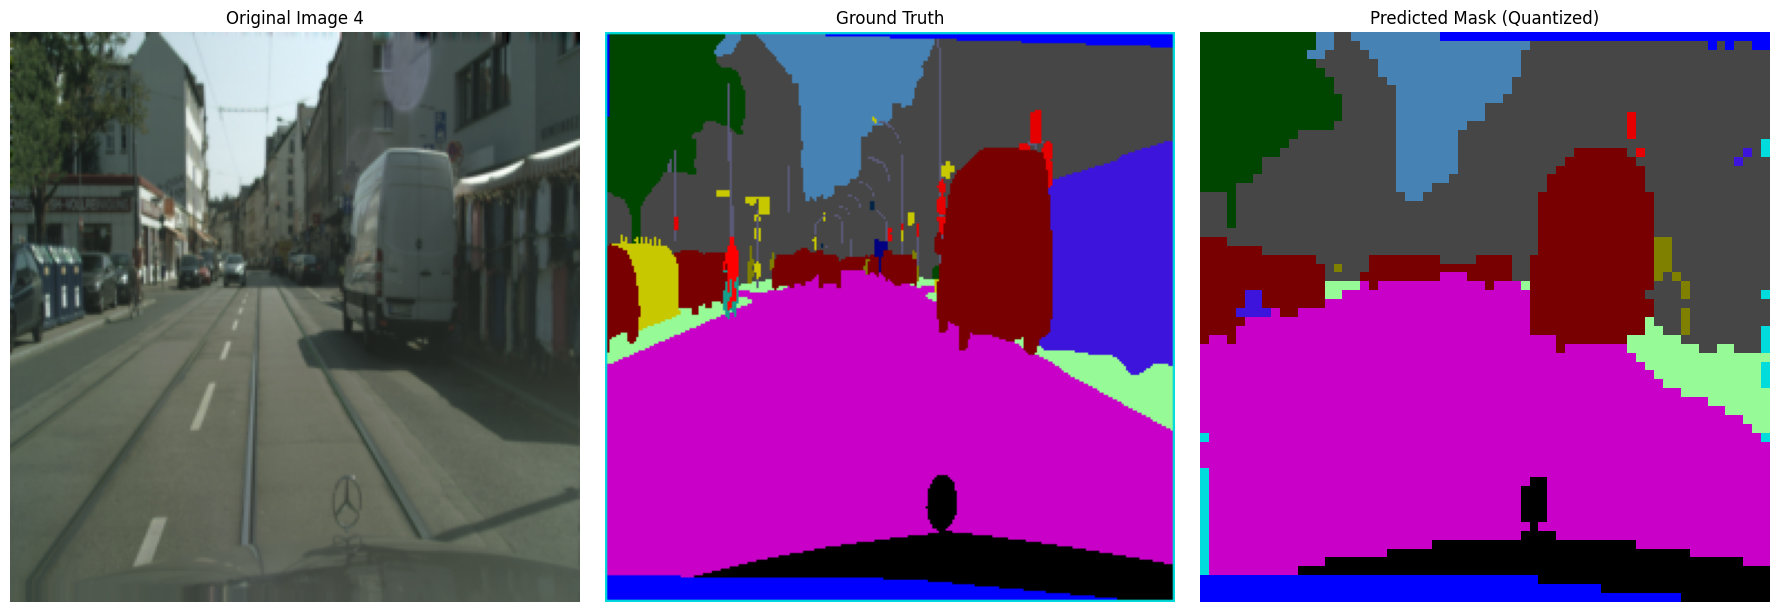

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import torch

# Giả sử bạn đã có: COLORMAP (list các màu RGB), unnorm (hàm đảo ngược normalization)
# và session ONNX đã được load.

with torch.inference_mode():
    for i in range(0, 5): # Thử với 5 ảnh đầu tiên cho nhanh
        features, labels = val_dataset[i]

        # 1. Chuẩn bị Input (Lưu ý: ONNX cần Numpy)
        img_tensor = features['image']
        imu_mask_tensor = features['imu_mask']

        # Thêm batch dim và chuyển sang numpy
        input_image = img_tensor.unsqueeze(0).numpy().astype(np.float32)
        input_imu_mask = imu_mask_tensor.unsqueeze(0).numpy().astype(np.float32)

        # 2. Chạy ONNX Inference
        outputs = session.run([output_name], {
            input_image_name: input_image,
            input_imu_mask_name: input_imu_mask
        })

        # 3. Hậu xử lý kết quả (Post-processing)
        # outputs[0] có shape (1, C, H, W)
        pred_logits = outputs[0][0] # Lấy ảnh đầu tiên trong batch -> (C, H, W)
        output_idx = np.argmax(pred_logits, axis=0) # Tìm class có xác suất cao nhất -> (H, W)

        # 4. Lấy Ground Truth
        # Giả sử labels['segmentation'] là mask dạng index (H, W)
        mask_idx = labels['segmentation'].numpy()
        if mask_idx.ndim == 3: # Nếu GT là one-hot (C, H, W)
            mask_idx = np.argmax(mask_idx, axis=0)

        # 5. Vẽ ảnh
        plt.figure(figsize=(18, 6))

        # --- Ảnh gốc ---
        plt.subplot(131)
        # unnorm giúp đưa ảnh từ dạng normalized về dạng 0-255 để nhìn được
        original_img = unorm(img_tensor).permute(1, 2, 0).cpu().numpy()
        plt.imshow(np.clip(original_img, 0, 1))
        plt.title(f"Original Image {i}")
        plt.axis('off')

        # --- Ground Truth Mask ---
        plt.subplot(132)
        gt_color = np.zeros((*mask_idx.shape, 3), dtype=np.uint8)
        for cls_id, color in enumerate(COLORMAP):
            gt_color[mask_idx == cls_id] = color
        plt.imshow(gt_color)
        plt.title("Ground Truth")
        plt.axis('off')

        # --- Predicted Mask (ONNX Quantized) ---
        plt.subplot(133)
        pred_color = np.zeros((*output_idx.shape, 3), dtype=np.uint8)
        for cls_id, color in enumerate(COLORMAP):
            pred_color[output_idx == cls_id] = color
        plt.imshow(pred_color)
        plt.title("Predicted Mask (Quantized)")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

In [ ]:
#predict

test_dataset = MyDataset(root_dir=os.path.join(electraawais_cityscape_dataset_path, "Cityscape Dataset/leftImg8bit/test"),
                          transform=test_transform
                          )
with torch.inference_mode():
    for i in range(0, 10): # Thử với 5 ảnh đầu tiên cho nhanh
        features, labels = test_dataset[i]

        # 1. Chuẩn bị Input (Lưu ý: ONNX cần Numpy)
        img_tensor = features['image']
        imu_mask_tensor = features['imu_mask']

        # Thêm batch dim và chuyển sang numpy
        input_image = img_tensor.unsqueeze(0).numpy().astype(np.float32)
        input_imu_mask = imu_mask_tensor.unsqueeze(0).numpy().astype(np.float32)

        # 2. Chạy ONNX Inference
        outputs = session.run([output_name], {
            input_image_name: input_image,
            input_imu_mask_name: input_imu_mask
        })

        # 3. Hậu xử lý kết quả (Post-processing)
        # outputs[0] có shape (1, C, H, W)
        pred_logits = outputs[0][0] # Lấy ảnh đầu tiên trong batch -> (C, H, W)
        output_idx = np.argmax(pred_logits, axis=0) # Tìm class có xác suất cao nhất -> (H, W)

        # 4. Lấy Ground Truth
        # Giả sử labels['segmentation'] là mask dạng index (H, W)
        mask_idx = labels['segmentation'].numpy()
        if mask_idx.ndim == 3: # Nếu GT là one-hot (C, H, W)
            mask_idx = np.argmax(mask_idx, axis=0)

        # 5. Vẽ ảnh
        plt.figure(figsize=(12, 6))

        # --- Ảnh gốc ---
        plt.subplot(121)
        # unnorm giúp đưa ảnh từ dạng normalized về dạng 0-255 để nhìn được
        original_img = unorm(img_tensor).permute(1, 2, 0).cpu().numpy()
        plt.imshow(np.clip(original_img, 0, 1))
        plt.title(f"Original Image {i}")
        plt.axis('off')

        # --- Predicted Mask (ONNX Quantized) ---
        plt.subplot(122)
        pred_color = np.zeros((*output_idx.shape, 3), dtype=np.uint8)
        for cls_id, color in enumerate(COLORMAP):
            pred_color[output_idx == cls_id] = color
        plt.imshow(pred_color)
        plt.title("Predicted Mask (Quantized)")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

IndexError: list index out of range

In [ ]:
!rm -r /kaggle/working/eWaSR2
!rm -r MyTorchPruning